In [ ]:
!pip install -q transformers

In [ ]:
from transformers import RobertaTokenizerFast, TFRobertaForSequenceClassification, pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sentiment_pipeline = pipeline("sentiment-analysis")
data = ["I love you", "I hate you"]
sentiment_pipeline(data)

In [ ]:
# download pre-trained emotion classification model
emotion = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base")

emotion(data)

In [ ]:
df = pd.read_csv('Arabasta.csv')

In [ ]:
df.head(5)

,web-scraper-order,web-scraper-start-url,link,link-href,comment
0,1735056604-20,https://transcripts.foreverdreaming.org/viewfo...,01x61 - An Angry Showdown! Cross the Red Line!,https://transcripts.foreverdreaming.org/viewto...,End of anger! To cross Red Line! A cemetery of...
1,1735056612-21,https://transcripts.foreverdreaming.org/viewfo...,02x62 - The First Obstacle? Giant Whale Laboon...,https://transcripts.foreverdreaming.org/viewto...,''Upper Yard'' ''Lovely Street''\n\n''Angel Be...
2,1735056615-22,https://transcripts.foreverdreaming.org/viewfo...,02x63 - A Man's Promise! Luffy and the Whale V...,https://transcripts.foreverdreaming.org/viewto...,''Upper Yard'' ''Lovely Street''\n\n''Angel Be...
3,1735056618-23,https://transcripts.foreverdreaming.org/viewfo...,02x65 - expl*si*n! The Three Swords Style! Zor...,https://transcripts.foreverdreaming.org/viewto...,Divine Plugging Protection Technique with 2 sa...
4,1735056620-24,https://transcripts.foreverdreaming.org/viewfo...,"02x66 - All Out Battle! Luffy vs. Zoro, Myster...",https://transcripts.foreverdreaming.org/viewto...,''Upper Yard'' ''Lovely Street''\n\n''Angel Be...


In [ ]:
df.drop(['web-scraper-order', 'web-scraper-start-url'], axis=1, inplace=True)

In [ ]:
df.head(5)

,link,link-href,comment
0,01x61 - An Angry Showdown! Cross the Red Line!,https://transcripts.foreverdreaming.org/viewto...,End of anger! To cross Red Line! A cemetery of...
1,02x62 - The First Obstacle? Giant Whale Laboon...,https://transcripts.foreverdreaming.org/viewto...,''Upper Yard'' ''Lovely Street''\n\n''Angel Be...
2,02x63 - A Man's Promise! Luffy and the Whale V...,https://transcripts.foreverdreaming.org/viewto...,''Upper Yard'' ''Lovely Street''\n\n''Angel Be...
3,02x65 - expl*si*n! The Three Swords Style! Zor...,https://transcripts.foreverdreaming.org/viewto...,Divine Plugging Protection Technique with 2 sa...
4,"02x66 - All Out Battle! Luffy vs. Zoro, Myster...",https://transcripts.foreverdreaming.org/viewto...,''Upper Yard'' ''Lovely Street''\n\n''Angel Be...


In [ ]:
MAX_LENGTH = 512  # ขีดจำกัดของโมเดล
df['comment'] = df['comment'].apply(lambda x: x[:MAX_LENGTH] if isinstance(x, str) else "")
#ตัดข้อความให้สั้นลงก่อนประมวลผล

In [ ]:
df['comment'] = df['comment'].str.replace('\n', '').str.replace('\r', '').str.replace('', '')

In [ ]:
df['sentiment'] = df.comment.apply(lambda x: sentiment_pipeline(x)[0]['label'])

In [ ]:
df['emotion'] = df.comment.apply(lambda x: emotion(x)[0]['label'])

In [ ]:
df.head(5)

,link,link-href,comment,sentiment,emotion
0,01x61 - An Angry Showdown! Cross the Red Line!,https://transcripts.foreverdreaming.org/viewto...,End of anger! To cross Red Line! A cemetery of...,POSITIVE,anger
1,02x62 - The First Obstacle? Giant Whale Laboon...,https://transcripts.foreverdreaming.org/viewto...,''Upper Yard'' ''Lovely Street''''Angel Beach'...,POSITIVE,sadness
2,02x63 - A Man's Promise! Luffy and the Whale V...,https://transcripts.foreverdreaming.org/viewto...,''Upper Yard'' ''Lovely Street''''Angel Beach'...,POSITIVE,surprise
3,02x65 - expl*si*n! The Three Swords Style! Zor...,https://transcripts.foreverdreaming.org/viewto...,Divine Plugging Protection Technique with 2 sa...,POSITIVE,sadness
4,"02x66 - All Out Battle! Luffy vs. Zoro, Myster...",https://transcripts.foreverdreaming.org/viewto...,''Upper Yard'' ''Lovely Street''''Angel Beach'...,NEGATIVE,anger


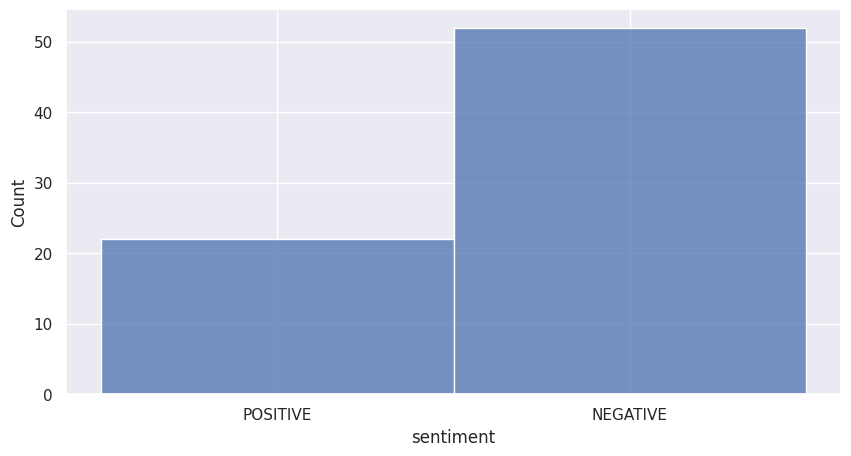

In [ ]:
sns.set(rc={'figure.figsize':(10,5)})
fig = sns.histplot(df['sentiment'])

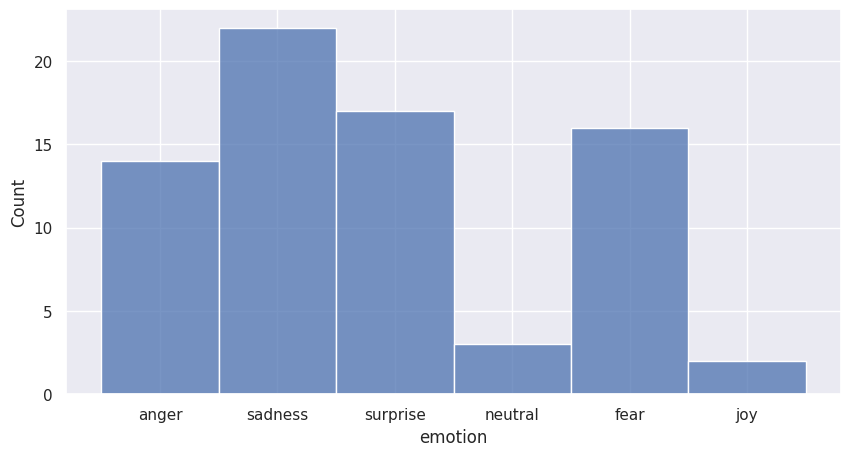

In [ ]:
sns.set(rc={'figure.figsize':(10,5)})
fig = sns.histplot(df['emotion'])

In [ ]:
df.to_csv('SoothingRelaxation-done.csv', index=False)

In [ ]:
from wordcloud import WordCloud
from wordcloud import STOPWORDS

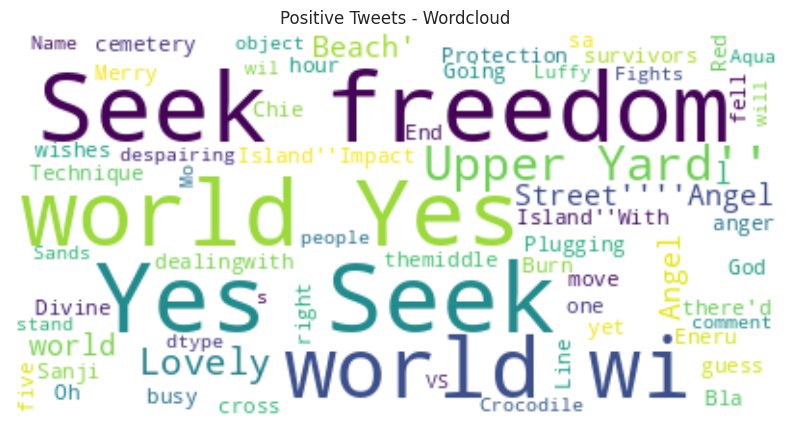

In [ ]:
# Wordcloud with positive
msg = df['comment'][df["sentiment"] == 'POSITIVE']
stop_words = list(STOPWORDS)
positive_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Positive Tweets - Wordcloud")
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


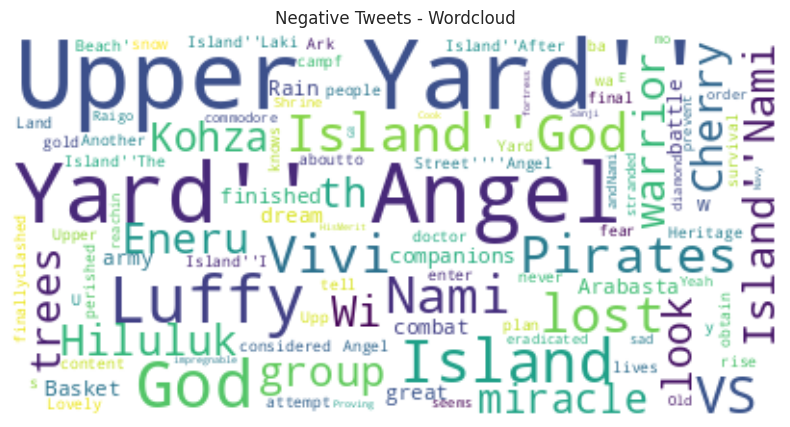

In [ ]:
 # Wordcloud with negative
msg = df['comment'][df["sentiment"] == 'NEGATIVE']
stop_words = ["https", "co", "RT"] + list(STOPWORDS)
negative_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Negative Tweets - Wordcloud")
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


In [ ]:
msg = df['comment']
stop_words = ["https", "co", "RT"] + list(STOPWORDS)
negative_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Negative Tweets - Wordcloud")
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


In [ ]:
msg = df['comment'][df['emotion'] == 'JOY']
stop_words = ["https", "co", "RT"] + list(STOPWORDS)
negative_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Negative Tweets - Wordcloud")
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()
